# Searching for Correlates in Neural Recordings — Circular Analysis ("Double Dipping")

## Motivation

The purpose of this exercise is to explore how a data-analysis *workflow* can influence
the validity of a study, and to show how simulations can be used to validate an analysis
workflow **before** applying it to real data — or even before collecting data.

We use an example from systems neuroscience. In many studies, researchers record from large
populations of individual cells (neurons) while an animal performs a task, and search for
cells whose activity is correlated with the animal's **behavioral performance** (for
example, its accuracy on a perceptual *discrimination* task). A common initial step may be to group those cells into "cell types" either based on their response patterns or based on measurements in another modality (ie cell morphology from EM), before running additional analysis on such groups.

Here's what might seem like a reasonable workflow following this pattern:

1. Identify the cells whose activity correlates with behavioral discrimination performance.
2. Average the activity across those identified cells (a "group of responsive cells").
3. Test how well this aggregate "responsive cell-group activity" score correlates with
   discrimination performance.

We simulate this experiment and analysis in two cases:

- **Question 1 — ground truth is *no effect*** (cell activity is unrelated to discrimination performance).
- **Question 2 — ground truth is a *real effect*** (discrimination performance genuinely modulates cell activity).

The key lesson: selecting cells by their correlation with performance and then re-testing
that same correlation on the selected cells produces a spurious "significant" result even
when there is no real effect.

**Dependencies:** `numpy`, `matplotlib`, `scipy` (only for statistics).



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

## Helper: column-wise correlation

For each cell (column) of the activity matrix `DA`, we compute the Pearson correlation `r`
with the behavioral performance vector and its two-tailed p-value `p`, in a vectorized way.


In [2]:
def corr_columns(X, y):
    """Pearson correlation of each column of X (n x p) with vector y (n,).

    Returns (r, p) each of length p.
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    with np.errstate(divide="ignore", invalid="ignore"):
        r = (Xc * yc[:, None]).sum(axis=0) / denom
    r = np.clip(r, -1.0, 1.0)
    df = n - 2
    with np.errstate(divide="ignore", invalid="ignore"):
        t = r * np.sqrt(df / (1 - r ** 2))
    p = 2 * stats.t.sf(np.abs(t), df)
    return r, p


def bestfit_line(ax, x, y):
    """Plot the least-squares best fit line."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    b, a = np.polyfit(x, y, 1)  # slope, intercept
    xl = np.array(ax.get_xlim())
    ax.plot(xl, b * xl + a, "-", color="tab:orange")
    ax.set_xlim(xl)


# Preparations

Suppose we tested `Nsubj = 12` animals in a study involving a behavioral discrimination task
and large-scale recording of neural activity.

## Animals and behavioral discrimination performance

First, for each animal we measure its behavioral performance on a perceptual discrimination
task, giving a performance score $P$ (e.g. percent correct). To simulate this, we draw a
score for each animal at random from a normal distribution with mean $\mu_P = 75$ and
standard deviation $\sigma_P = 8$.

(Rounding $P$ to an integer percent is not required — it just mimics a realistic performance
measure.)



In [3]:
Nsubj = 12
mP, sP = 75, 8
Perf = sP * rng.standard_normal(Nsubj) + mP
Perf = np.round(Perf)  # not required, but make performance an integer percent
Perf


array([76., 74., 80., 76., 71., 78., 85., 83., 69., 65., 70., 75.])

## Simulating the calcium imaging recording (cell setup)

For each animal we simulate a calcium imaging recording measuring the increase in activity of
each cell in a stimulus condition relative to a control condition — the *differential
activity*. This is measured separately in each of `Ncells = 5000` imaged cells (neurons). For
simplicity we assume we can identify the corresponding cells in all 12 animals and that the
same cells are modulated by the task in every animal. We keep the cells in a 1D vector.

We simulate that **10% of the cells really are driven** by the stimulus
("stimulus-responsive cells"), with differential activity drawn from a normal distribution
with $\mu_A = 1$, $\sigma_A = 1$. The remaining cells have no difference in activity on
average ("non-responsive cells"), drawn from a normal distribution with $\mu_B = 0$,
$\sigma_B = \sigma_A$.

**Here's the key point:** although the differential activity really is related to the
stimulus (some cells genuinely respond), in Question 1 that activity is *completely unrelated
to behavioral discrimination performance in any cell*. Let's see how often we would be fooled
into thinking cell activity and discrimination performance are related, when we know they are
not.



In [4]:
Ncells = 5000
Nresponsive = round(0.1 * Ncells)
StimulusResponsiveCells = np.arange(0, Nresponsive)
NonResponsiveCells = np.arange(Nresponsive, Ncells)

print(StimulusResponsiveCells.shape)
print(NonResponsiveCells.shape)
print(Nresponsive)


(500,)
(4500,)
500


# Question 1 — Standard analysis method, **no real effect**

We replicate a common data-analysis workflow to identify cells whose activity correlates
with behavioral discrimination performance:

1. **Correlate each cell with performance.** For each of the `Ncells` cells, take the
   12 animals' differential-activity values and the 12 animals' performance scores $P$ and
   test whether they are correlated. This gives `Ncells` $r$ values and $p$ values.
2. **Define the "selected" cells** as all cells *positively* correlated with $P$ under
   the criteria $r > 0.1$ **and** $p < 0.05$. (These may or may not be stimulus-responsive cells.)
3. **Average within each animal** the differential activity of the selected cells to get a
   single "Relevant Cell-Group Activity" (RCGA) value per animal.
4. **Scatter plot** RCGA versus performance $P$ (1 symbol per animal, 12 animals).
5. **Fit a line** and label the plot with the $R^2$ and $p$ values (done in the plotting cell below).

First, simulate the null data set. Stimulus-responsive cells are drawn with mean `mA`, std `sA`;
non-responsive cells with mean 0, std `sA`. Crucially, the cell activity does **not**
depend on `Perf`, so there is no true relationship between cell activity and performance.



In [5]:
mA, sA = 1, 1
DA = np.empty((Nsubj, Ncells))
DA[:, StimulusResponsiveCells] = sA * rng.standard_normal((Nsubj, Nresponsive)) + mA
DA[:, NonResponsiveCells] = sA * rng.standard_normal((Nsubj, Ncells - Nresponsive))
print(DA)


[[-1.32503077  0.78120834 -0.24591095 ... -0.67797236  1.00727475
  -1.34826718]
 [ 0.45604228  0.86654844  2.29787176 ... -0.24518304 -0.51283528
   0.0212667 ]
 [ 0.96525288  0.34762189 -0.0540028  ...  1.69128779  0.02544526
  -0.42172055]
 ...
 [ 0.52386923  1.3558794   0.3045728  ...  0.41248303  0.69676562
   0.96407547]
 [-0.59567991  1.25448862 -0.72232481 ... -1.0334474   1.38470178
   0.46952627]
 [ 0.8386316   0.25315834  2.70167708 ... -0.44171935 -0.34363016
   0.5598252 ]]


In [6]:
# 1. Correlate each cell's differential activity with discrimination performance.
r, p = corr_columns(DA, Perf)

# 2. "Selected" cells: positive correlation r > 0.1 AND significant p < 0.05.
SelectedCells = np.where((r > 0.1) & (p < 0.05))[0]

# 3. Average the differential activity of the selected cells within each animal.
RCGA = DA[:, SelectedCells].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells.size}")
print(f"RCGA shape (should be {Nsubj}): {RCGA.shape}")


Number of 'selected' cells: 119
RCGA shape (should be 12): (12,)


# Question 2 — Standard analysis method, **with a real effect**

Now we repeat the entire simulation, but this time behavioral discrimination performance
really *does* predict how strongly the stimulus modulates cell activity in the
stimulus-responsive cells. Instead of using a fixed mean $\mu_A$ for the stimulus-responsive
cells, we use $\mu_A(i) = f(P(i))$, a function of each animal's performance.

We contrive $f$ so that the **average** value of $\mu_A(i)$ is the same as the fixed $\mu_A$
used in the null simulation (so overall activity levels match), while $\mu_A(i)$ is
*noticeably but only modestly* correlated with $P(i)$. Concretely we use a scaled, shifted
version of $P$:

$$P_\text{scaled} = \frac{k\, \sigma_A}{\operatorname{std}(P)}\,(P - \overline{P}) + \mu_A$$

The constant `k` sets how big the behavioral effect is relative to noise:
`k=1` → the stimulus-driven signal is mostly determined by performance; `k=0.1` → performance only
weakly affects it. Here `k=0.2` gives a modest correlation. Then the rest of the analysis
workflow is applied exactly as in Question 1.



In [7]:
k = 0.2  # modest correlation between stimulus-driven signal and performance
Pscaled = (k * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf)) + mA

DA_real = np.empty((Nsubj, Ncells))
for i in range(Nsubj):
    DA_real[i, StimulusResponsiveCells] = (
        sA * rng.standard_normal(Nresponsive) + Pscaled[i]
    )
DA_real[:, NonResponsiveCells] = sA * rng.standard_normal((Nsubj, Ncells - Nresponsive))

r2, p2 = corr_columns(DA_real, Perf)
SelectedCells_real = np.where((r2 > 0.1) & (p2 < 0.05))[0]
RCGA_real = DA_real[:, SelectedCells_real].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real.size}")


Number of 'selected' cells: 152


## Plot both cases

For each animal, plot Relevant Cell-Group Activity (RCGA) vs. their behavioral
discrimination performance, with the best-fit line and the $R^2$ / p-value of the (circular)
correlation. Note that even the "no real effect" case tends to look significant —
that is the double-dipping artifact.


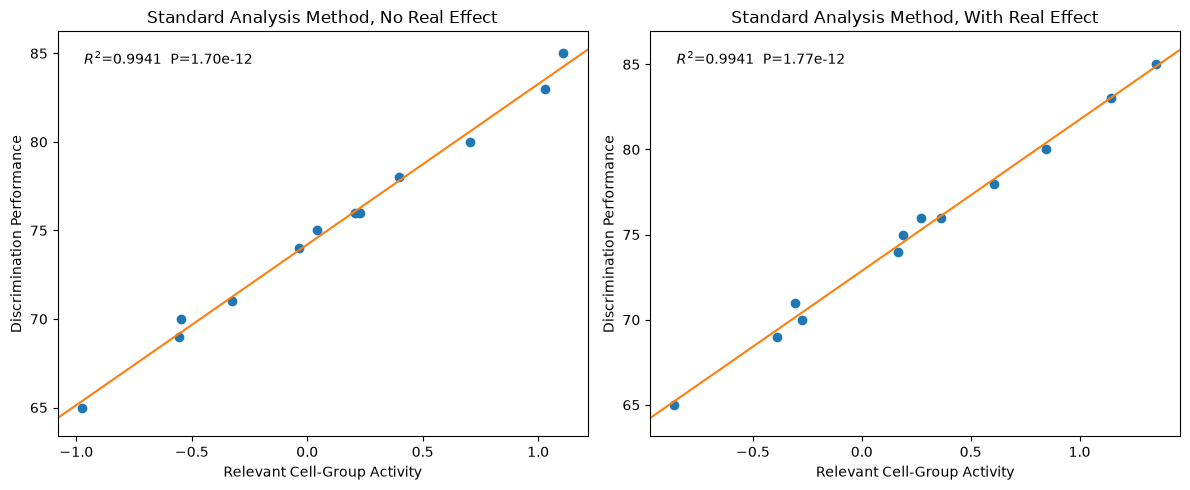

In [8]:
def annotate_corr(ax, rcga, Perf, title):
    ax.plot(rcga, Perf, "o", color="tab:blue", markerfacecolor="tab:blue")
    bestfit_line(ax, rcga, Perf)
    ax.set_xlabel("Relevant Cell-Group Activity")
    ax.set_ylabel("Discrimination Performance")
    ax.set_title(title)
    r_model, p_model = stats.pearsonr(rcga, Perf)
    Rsquared = r_model ** 2
    xlims, ylims = ax.get_xlim(), ax.get_ylim()
    xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
    ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
    ax.text(xpos, ypos, f"$R^2$={Rsquared:.4f}  P={p_model:.2e}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
annotate_corr(axes[0], RCGA, Perf, "Standard Analysis Method, No Real Effect")
annotate_corr(axes[1], RCGA_real, Perf, "Standard Analysis Method, With Real Effect")
plt.tight_layout()
plt.show()


## What to think about (interpreting the two plots)

Compare the two panels. In the **left** panel (no real effect) the ground truth is that
cell activity is completely unrelated to discrimination performance — yet the scatter typically
shows a convincing-looking positive trend with a high $R^2$ and a small $p$ value. This is a
**false positive**. In the **right** panel (real effect) we see a similar-looking trend.

The uncomfortable observation: the false positive from the null simulation looks about as
convincing — in $R^2$, $p$ value, and scatter plot — as the true positive. On the strength of
these plots alone you generally *cannot* tell a false positive from a real effect.

*(Optional extension, per step 6 of the assignment: wrap the Question 1 simulation in a loop
that draws a fresh random null data set 1,000–10,000 times, and count what fraction of runs
produce a "significant" result, e.g. $p < 0.01$. You would find the false-positive rate is far
above the nominal 1%.)*

## Question 3 — What is wrong with this workflow?

The flaw is **circular analysis**, also called **"double dipping"** or non-independence
error. The *same* 12 animals' data are used twice:

1. First to **select** the cells — we keep exactly those cells that happen to correlate
   positively with $P$ in this particular sample.
2. Then to **test** the correlation — we re-measure the correlation between $P$ and the average
   of those hand-picked cells.

Because the selection step cherry-picks cells whose *noise* happens to align with $P$, the
averaged cell group is guaranteed to correlate with $P$ in the same sample even when no true
relationship exists. The final correlation test is therefore not valid: its null distribution
is not the standard one, so the reported $p$ value is meaningless.

**A better (independent) workflow** — split the data so that selection and testing use
different observations. For example:

- **Cross-validation / data splitting:** select the "responsive" cells using one subset of
  animals (or recording sessions), then compute RCGA and test its correlation with $P$ on a *held-out*
  subset that played no part in selection.
- **A fully independent localizer:** define the cell set from separate data (e.g. an
  independent stimulus-response recording), then apply it to the experimental data.

Applied to the null data (Question 1) this independent approach brings the false-positive rate
back down to the nominal level (~1% at $p<0.01$), so spurious correlations largely disappear.
Applied to the real-effect data (Question 2) it still detects the genuine effect — with lower
power than the (invalid) circular method, but with a trustworthy $p$ value.



---

# SOLUTION: Leave-one-out cross-validation 
Break the circularity by using different sets of animals to select the cells and test the correlation.

With only 12 animals, **leave-one-out cross-validation (LOO-CV)** is a natural choice:

* **Fold $i$** (for $i = 1 \ldots N_\text{subj}$):
  1. Use the $N_\text{subj} - 1$ *training* animals to select cells
     (same criteria as before: $r > 0.1$, $p < 0.05$).
  2. Compute the RCGA for the *held-out* animal $i$ by averaging the
     activity in those training-derived cells.

After all folds, the held-out RCGA values are assembled into a vector of length
$N_\text{subj}$ and correlated with $P$.  Because no animal's data influenced both the
cell-selection step and its own RCGA value, this correlation is statistically valid.

The helper below implements the loop; it returns `RCGA_cv` (one entry per animal) and
the number of cells selected in each fold (useful for diagnostics).


In [9]:
def loo_cv_rcga(DA, Perf):
    """Leave-one-out cross-validated RCGA.

    For each held-out animal i, cells are selected on the other N-1 animals
    using the same criteria as the standard analysis (r > 0.1, p < 0.05),
    then RCGA is computed for animal i on those held-out cells.

    Returns
    -------
    RCGA_cv : ndarray, shape (Nsubj,)
        Cross-validated RCGA; NaN where no cells were selected in that fold.
    n_cells : list of int
        Number of cells selected in each fold (diagnostic).
    """
    Nsubj = DA.shape[0]
    RCGA_cv = np.full(Nsubj, np.nan)
    n_cells = []

    for i in range(Nsubj):
        train_idx = np.delete(np.arange(Nsubj), i)
        r_tr, p_tr = corr_columns(DA[train_idx], Perf[train_idx])
        sel_cells = np.where((r_tr > 0.1) & (p_tr < 0.05))[0]
        n_cells.append(sel_cells.size)
        if sel_cells.size > 0:
            RCGA_cv[i] = DA[i, sel_cells].mean()

    return RCGA_cv, n_cells


In [10]:
# Apply LOO-CV to both datasets
RCGA_cv_null, ncells_null = loo_cv_rcga(DA, Perf)
RCGA_cv_real, ncells_real = loo_cv_rcga(DA_real, Perf)

print("Null data (no real effect):")
print(f"  Avg cells selected per fold : {np.mean(ncells_null):.1f}  "
      f"(range {min(ncells_null)}–{max(ncells_null)})")
print(f"  Folds with ≥1 cell selected : {np.sum(np.array(ncells_null) > 0)}/{Nsubj}")

print("\nReal-effect data:")
print(f"  Avg cells selected per fold : {np.mean(ncells_real):.1f}  "
      f"(range {min(ncells_real)}–{max(ncells_real)})")
print(f"  Folds with ≥1 cell selected : {np.sum(np.array(ncells_real) > 0)}/{Nsubj}")


Null data (no real effect):
  Avg cells selected per fold : 113.7  (range 107–133)
  Folds with ≥1 cell selected : 12/12

Real-effect data:
  Avg cells selected per fold : 149.3  (range 125–166)
  Folds with ≥1 cell selected : 12/12


### Comparison plots: circular analysis vs. LOO-CV

Four panels show the scatter of RCGA vs. discrimination performance $P$ for all four combinations.
In the LOO-CV plots only animals whose fold produced at least one selected cell are shown
(all animals in practice with `Ncells = 5000`).

**Expected outcome:** the null-data CV panel should show a weak, non-significant
correlation ($p \gg 0.05$) while the real-effect CV panel should still show a positive
trend, though with a less extreme $R^2$ than the (invalid) circular version.


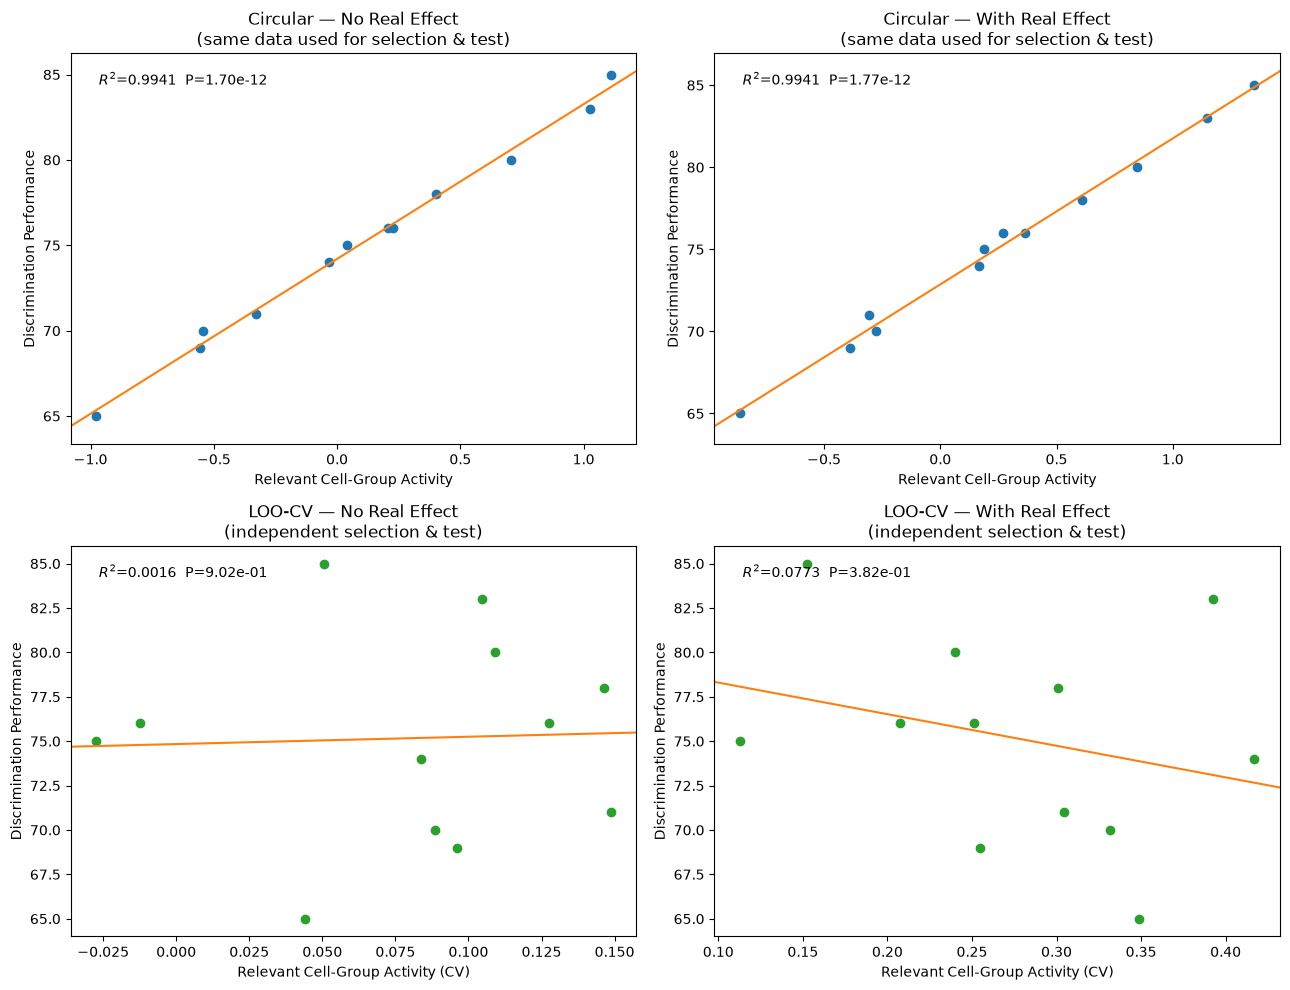

In [11]:
def annotate_corr_cv(ax, rcga, Perf, title):
    """Like annotate_corr but handles NaN entries from LOO-CV."""
    mask = ~np.isnan(rcga)
    rcga_valid, Perf_valid = rcga[mask], Perf[mask]
    ax.plot(rcga_valid, Perf_valid, "o", color="tab:green", markerfacecolor="tab:green")
    bestfit_line(ax, rcga_valid, Perf_valid)
    ax.set_xlabel("Relevant Cell-Group Activity (CV)")
    ax.set_ylabel("Discrimination Performance")
    ax.set_title(title)
    if Perf_valid.size >= 3:
        r_cv, p_cv = stats.pearsonr(rcga_valid, Perf_valid)
        Rsq = r_cv ** 2
        xlims, ylims = ax.get_xlim(), ax.get_ylim()
        xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
        ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
        ax.text(xpos, ypos, f"$R^2$={Rsq:.4f}  P={p_cv:.2e}")


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Row 1 — circular (standard) analysis
annotate_corr(axes[0, 0], RCGA, Perf,
              "Circular — No Real Effect\n(same data used for selection & test)")
annotate_corr(axes[0, 1], RCGA_real, Perf,
              "Circular — With Real Effect\n(same data used for selection & test)")

# Row 2 — LOO-CV (independent) analysis
annotate_corr_cv(axes[1, 0], RCGA_cv_null, Perf,
                 "LOO-CV — No Real Effect\n(independent selection & test)")
annotate_corr_cv(axes[1, 1], RCGA_cv_real, Perf,
                 "LOO-CV — With Real Effect\n(independent selection & test)")

plt.tight_layout()
plt.show()


### Rejecting the true positive?
This method prevents us from detecting the false positive in the no real effect dataset, but we also don't see a true positive result in the dataset with a real effect. What if we try increasing the strength of the real effect? 

In [12]:
# simulate a stronger effect, k = 0.5
k_strong = 0.5  # stronger correlation between stimulus-driven signal and performance
Pscaled_strong = (k_strong * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf)) + mA

DA_real_strong = np.empty((Nsubj, Ncells))
for i in range(Nsubj):
    DA_real_strong[i, StimulusResponsiveCells] = (
        sA * rng.standard_normal(Nresponsive) + Pscaled_strong[i]
    )
DA_real_strong[:, NonResponsiveCells] = sA * rng.standard_normal((Nsubj, Ncells - Nresponsive))

r2, p2 = corr_columns(DA_real_strong, Perf)
SelectedCells_real_strong = np.where((r2 > 0.1) & (p2 < 0.05))[0]
RCGA_real_strong = DA_real_strong[:, SelectedCells_real_strong].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real_strong.size}")


Number of 'selected' cells: 270


In [13]:
RCGA_cv_real_strong, ncells_real_strong = loo_cv_rcga(DA_real_strong, Perf)

print("\nWeak real-effect data:")
print(f"  Avg cells selected per fold : {np.mean(ncells_real):.1f}  "
      f"(range {min(ncells_real)}–{max(ncells_real)})")
print(f"  Folds with ≥1 cell selected : {np.sum(np.array(ncells_real) > 0)}/{Nsubj}")

print("\nStrong real-effect data:")
print(f"  Avg cells selected per fold : {np.mean(ncells_real_strong):.1f}  "
      f"(range {min(ncells_real_strong)}–{max(ncells_real_strong)})")
print(f"  Folds with ≥1 cell selected : {np.sum(np.array(ncells_real_strong) > 0)}/{Nsubj}")



Weak real-effect data:
  Avg cells selected per fold : 149.3  (range 125–166)
  Folds with ≥1 cell selected : 12/12

Strong real-effect data:
  Avg cells selected per fold : 256.4  (range 224–273)
  Folds with ≥1 cell selected : 12/12


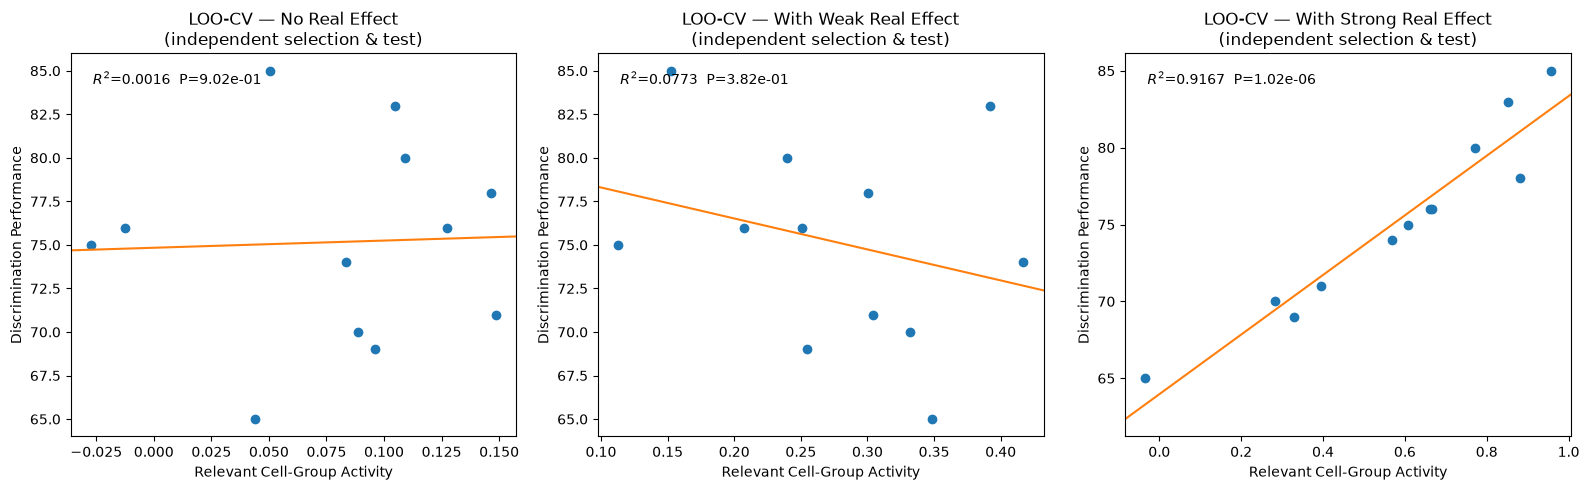

In [14]:
# plot the results for LOO-CV - no effect, weak effect, strong effect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


annotate_corr(axes[0], RCGA_cv_null, Perf,
             "LOO-CV — No Real Effect\n(independent selection & test)")


annotate_corr(axes[1], RCGA_cv_real, Perf,
              "LOO-CV — With Weak Real Effect\n(independent selection & test)")

annotate_corr(axes[2], RCGA_cv_real_strong, Perf,
              "LOO-CV — With Strong Real Effect\n(independent selection & test)")

plt.tight_layout()
plt.show()


---

## Alternative: Independent Cell Selection by Stimulus Response

The LOO-CV approach fixes double-dipping but pays a power cost: each fold's cells are
selected on only $N-1$ animals, and with $N=12$ and a weak effect ($k=0.2$) that is not
enough to reliably detect the true correlation.

A more powerful valid approach is to **change the cell-selection criterion** so that it
is independent of $P$ by construction.  Instead of selecting cells that correlate with
discrimination performance, we select cells that are **driven by the stimulus** — i.e., those
whose mean differential activity across animals is significantly greater than zero. This
defines a **group of stimulus-responsive cells** (a functional cell type).

Concretely, for each cell we run a one-sample $t$-test (across animals) against zero
and keep cells with $p < 0.05$ (one-tailed, testing mean $> 0$).  Because this criterion
does not involve $P$ at all, there is no circularity: the full $N=12$ animals can be
used for both selection and the subsequent correlation test.



In [15]:
def stimulus_based_rcga(DA):
    """Select cells by stimulus response (one-sample t-test, mean > 0, p < 0.05).

    The criterion involves only the stimulus response, never Perf, so no cross-validation
    is needed — all animals can be used for both selection and correlation.

    Returns
    -------
    RCGA_stim : ndarray, shape (Nsubj,)
    n_selected : int
    """
    n = DA.shape[0]
    cell_means = DA.mean(axis=0)
    cell_se = DA.std(axis=0, ddof=1) / np.sqrt(n)
    with np.errstate(divide="ignore", invalid="ignore"):
        t_vals = cell_means / cell_se
    p_vals = stats.t.sf(t_vals, df=n - 1)   # one-tailed: mean > 0
    selected = np.where(p_vals < 0.05)[0]
    RCGA_stim = DA[:, selected].mean(axis=1) if selected.size > 0 else np.full(n, np.nan)
    return RCGA_stim, selected.size


RCGA_stim_null, n_stim_null = stimulus_based_rcga(DA)
RCGA_stim_real, n_stim_real = stimulus_based_rcga(DA_real)
RCGA_stim_real_strong, n_stim_real_strong = stimulus_based_rcga(DA_real_strong)

print(f"Null data  — cells selected by stimulus response: {n_stim_null}")
print(f"Real data (weak effect)  — cells selected by stimulus response: {n_stim_real}")
print(f"Real data (strong effect)  — cells selected by stimulus response: {n_stim_real_strong}")


Null data  — cells selected by stimulus response: 661
Real data (weak effect)  — cells selected by stimulus response: 706
Real data (strong effect)  — cells selected by stimulus response: 685


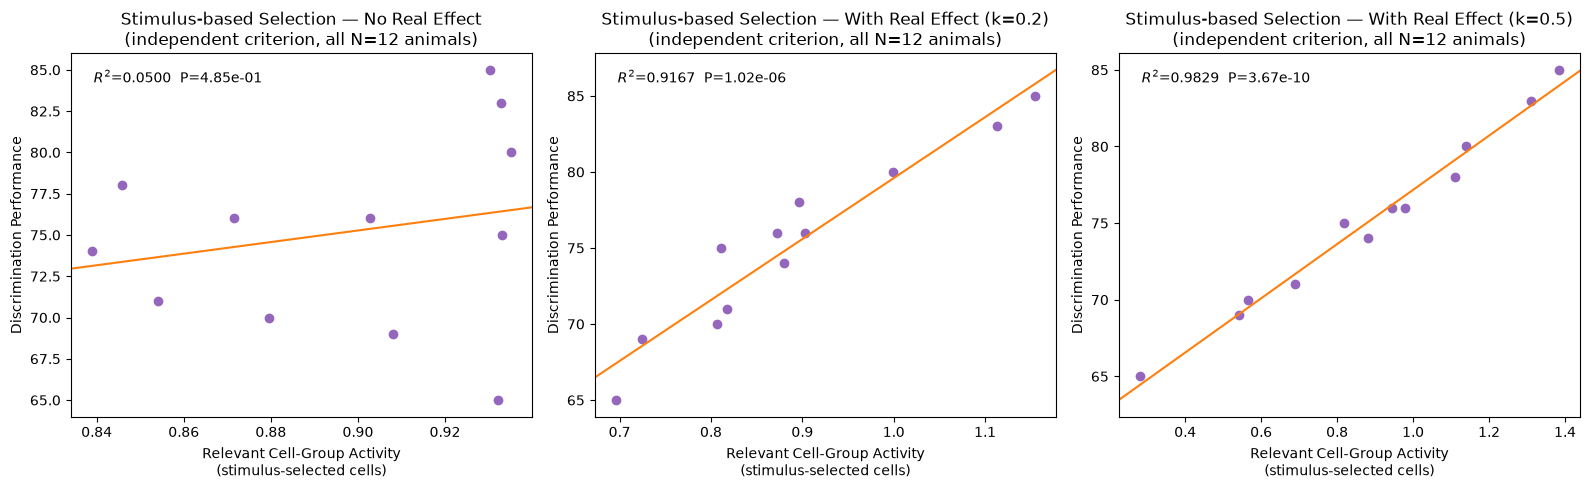

In [16]:
def annotate_corr_stim(ax, rcga, Perf, title, color="tab:purple"):
    """Scatter + best-fit line for stimulus-based RCGA (handles NaN)."""
    mask = ~np.isnan(rcga)
    rcga_v, Perf_v = rcga[mask], Perf[mask]
    ax.plot(rcga_v, Perf_v, "o", color=color, markerfacecolor=color)
    bestfit_line(ax, rcga_v, Perf_v)
    ax.set_xlabel("Relevant Cell-Group Activity\n(stimulus-selected cells)")
    ax.set_ylabel("Discrimination Performance")
    ax.set_title(title)
    if Perf_v.size >= 3:
        r_t, p_t = stats.pearsonr(rcga_v, Perf_v)
        Rsq = r_t ** 2
        xlims, ylims = ax.get_xlim(), ax.get_ylim()
        xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
        ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
        ax.text(xpos, ypos, f"$R^2$={Rsq:.4f}  P={p_t:.2e}")


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
annotate_corr_stim(axes[0], RCGA_stim_null, Perf,
                   "Stimulus-based Selection — No Real Effect\n(independent criterion, all N=12 animals)")
annotate_corr_stim(axes[1], RCGA_stim_real, Perf,
                   f"Stimulus-based Selection — With Real Effect (k={k})\n(independent criterion, all N=12 animals)")
annotate_corr_stim(axes[2], RCGA_stim_real_strong, Perf,
                   f"Stimulus-based Selection — With Real Effect (k={k_strong})\n(independent criterion, all N=12 animals)")
plt.tight_layout()
plt.show()


This method successfully returned no effect in the no effect dataset, but was able to detect a true positive in both the weak and strong effect datasets. 


### False-positive rate — all three methods



A single simulation run is not enough to measure the false-positive rate — one run
either passes or fails the significance threshold by chance.  To estimate the actual
false-positive rate we repeat the **null simulation** (no real effect) many times and
count how often each method incorrectly declares a significant result.

The loop below runs `N_iter = 1000` fresh null datasets.  For each:

1. Draw new `DA` (only `Perf` stays fixed — the design is fixed, the cell data are resampled).
2. Run the **circular** analysis and record whether the final $p < \alpha$.
3. Run the **LOO-CV** analysis and record whether the final $p < \alpha$.
4. Run the **Stimulus-based** analysis and record whether the final $p < \alpha$.

At $\alpha = 0.01$ the nominal false-positive rate is 1%.  We expect the circular
method to be *far* above that, and the LOO-CV and stimulus-based methods to be close to it.


| Method | Selection criterion | Animals used for selection | Animals used for final test |
|---|---|---|---|
| Circular | Correlation with $P$ | All 12 | Same 12 |
| LOO-CV | Correlation with $P$ | 11 (held one out) | All 12 (assembled) |
| Stimulus-based | Stimulus response (mean $> 0$) | All 12 | All 12 |

**Expected outcome:** circular far above nominal, LOO-CV and stimulus-based both near nominal (∼1%), with stimulus-based having somewhat better power to detect the real effect.


In [17]:
N_iter2 = 1000
alpha2 = 0.01

counts = {"circular": 0, "loo_cv": 0, "stimulus": 0}

for _ in range(N_iter2):
    DA_mc = np.empty((Nsubj, Ncells))
    DA_mc[:, StimulusResponsiveCells] = sA * rng.standard_normal((Nsubj, Nresponsive)) + mA
    DA_mc[:, NonResponsiveCells] = sA * rng.standard_normal((Nsubj, Ncells - Nresponsive))

    # Circular
    r_mc, p_mc = corr_columns(DA_mc, Perf)
    sel_mc = np.where((r_mc > 0.1) & (p_mc < 0.05))[0]
    if sel_mc.size > 0:
        _, p_circ = stats.pearsonr(DA_mc[:, sel_mc].mean(axis=1), Perf)
        if p_circ < alpha2:
            counts["circular"] += 1

    # LOO-CV
    RCGA_cv_mc, _ = loo_cv_rcga(DA_mc, Perf)
    mask = ~np.isnan(RCGA_cv_mc)
    if mask.sum() >= 3:
        _, p_cv = stats.pearsonr(RCGA_cv_mc[mask], Perf[mask])
        if p_cv < alpha2:
            counts["loo_cv"] += 1

    # Stimulus-based
    RCGA_stim_mc, n_sel = stimulus_based_rcga(DA_mc)
    if n_sel > 0:
        _, p_stim = stats.pearsonr(RCGA_stim_mc, Perf)
        if p_stim < alpha2:
            counts["stimulus"] += 1

for name, cnt in counts.items():
    print(f"  {name:10s}  FP rate = {cnt/N_iter2:.1%}  ({cnt}/{N_iter2})")
print(f"  nominal α  = {alpha2:.1%}")


  circular    FP rate = 100.0%  (1000/1000)
  loo_cv      FP rate = 9.4%  (94/1000)
  stimulus    FP rate = 0.4%  (4/1000)
  nominal α  = 1.0%


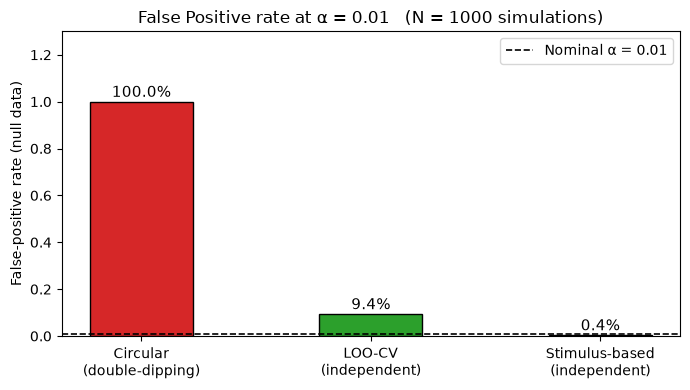

In [18]:
labels = ["Circular\n(double-dipping)", "LOO-CV\n(independent)", "Stimulus-based\n(independent)"]
rates2 = [counts[k] / N_iter2 for k in ("circular", "loo_cv", "stimulus")]
colors2 = ["tab:red", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, rates2, color=colors2, width=0.45, edgecolor="k")
ax.axhline(alpha2, color="k", linestyle="--", linewidth=1.2, label=f"Nominal α = {alpha2}")
ax.set_ylabel("False-positive rate (null data)")
ax.set_title(f"False Positive rate at α = {alpha2}   (N = {N_iter2} simulations)")
ax.set_ylim(0, max(rates2) * 1.3)
for bar, rate in zip(bars, rates2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


---

## Power Curves: Effect Size and Sample Size Sweeps

Here we measure **power** — the true-positive rate on real-effect data — across two parameter sweeps:

1. **Effect-size sweep** — $k$ from 0.1 to 1.0 in steps of 0.1, with $N = 12$ fixed.
   Shows the minimum effect size each method can reliably detect.

2. **Sample-size sweep** — $N$ from 5 to 25 in steps of 1, with $k = 0.2$ fixed.
   Shows how many animals each method needs to reach adequate power.

For each combination, `N_iter_power` real-effect datasets are simulated and the
fraction of runs that produce $p < \alpha$ is recorded.  $P$ and the cell layout are
resampled fresh each run so the estimate reflects genuine variability.

> **Note on the circular method:** its "power" includes spurious detections arising
> from the circular selection bias — the high curve is not evidence of a trustworthy
> method, but of an inflated false-positive rate carrying over into real-effect data.


In [19]:
def power_sweep(param_values, param_name, N_iter, alpha, k_fixed=0.2, N_fixed=12):
    """Estimate detection power for each value of k (effect size) or N (sample size).

    Simulates real-effect data for each parameter value and returns the fraction
    of runs where each method correctly reaches p < alpha.

    Parameters
    ----------
    param_values : array-like
    param_name   : 'k' or 'N'
    N_iter       : simulations per parameter value
    alpha        : significance threshold
    k_fixed      : effect size used when sweeping N
    N_fixed      : sample size used when sweeping k
    """
    power = {m: [] for m in ("circular", "loo_cv", "stimulus")}

    for val in param_values:
        k_val = float(val) if param_name == "k" else k_fixed
        N_val = int(val)   if param_name == "N" else N_fixed
        counts = {"circular": 0, "loo_cv": 0, "stimulus": 0}

        for _ in range(N_iter):
            # Fresh performance scores for this run
            Perf_sim = np.round(sP * rng.standard_normal(N_val) + mP)
            std_P = np.std(Perf_sim, ddof=1)
            if std_P < 1e-10:
                continue

            # Real-effect cell data: stimulus-responsive cells modulated by performance
            Pscaled_sim = (k_val * sA / std_P) * (Perf_sim - np.mean(Perf_sim)) + mA
            DA_sim = sA * rng.standard_normal((N_val, Ncells))
            DA_sim[:, StimulusResponsiveCells] += Pscaled_sim[:, np.newaxis]

            # Circular
            r_s, p_s = corr_columns(DA_sim, Perf_sim)
            sel_s = np.where((r_s > 0.1) & (p_s < 0.05))[0]
            if sel_s.size > 0:
                _, p_circ = stats.pearsonr(DA_sim[:, sel_s].mean(axis=1), Perf_sim)
                if p_circ < alpha:
                    counts["circular"] += 1

            # LOO-CV
            RCGA_cv_s, _ = loo_cv_rcga(DA_sim, Perf_sim)
            cv_mask = ~np.isnan(RCGA_cv_s)
            if cv_mask.sum() >= 3:
                _, p_cv = stats.pearsonr(RCGA_cv_s[cv_mask], Perf_sim[cv_mask])
                if p_cv < alpha:
                    counts["loo_cv"] += 1

            # Stimulus-based
            RCGA_stim_s, n_sel = stimulus_based_rcga(DA_sim)
            if n_sel > 0:
                _, p_stim = stats.pearsonr(RCGA_stim_s, Perf_sim)
                if p_stim < alpha:
                    counts["stimulus"] += 1

        for m in power:
            power[m].append(counts[m] / N_iter)

    return power


In [20]:
N_iter_power = 200   # increase to 500–1000 for smoother curves (takes longer)
alpha_power  = 0.05  # standard threshold for power analysis

k_values = np.round(np.arange(0.1, 1.01, 0.1), 2)   # [0.1, 0.2, ..., 1.0]
N_values = np.arange(5, 26, 1)                        # [5, 6, ..., 25]

print(f"Running effect-size sweep ({len(k_values)} k values × {N_iter_power} iterations) …")
power_k = power_sweep(k_values, "k", N_iter_power, alpha_power, N_fixed=12)
print("  done.")

print(f"Running sample-size sweep ({len(N_values)} N values × {N_iter_power} iterations) …")
power_N = power_sweep(N_values, "N", N_iter_power, alpha_power, k_fixed=0.2)
print("  done.")

Running effect-size sweep (10 k values × 200 iterations) …
  done.
Running sample-size sweep (21 N values × 200 iterations) …
  done.


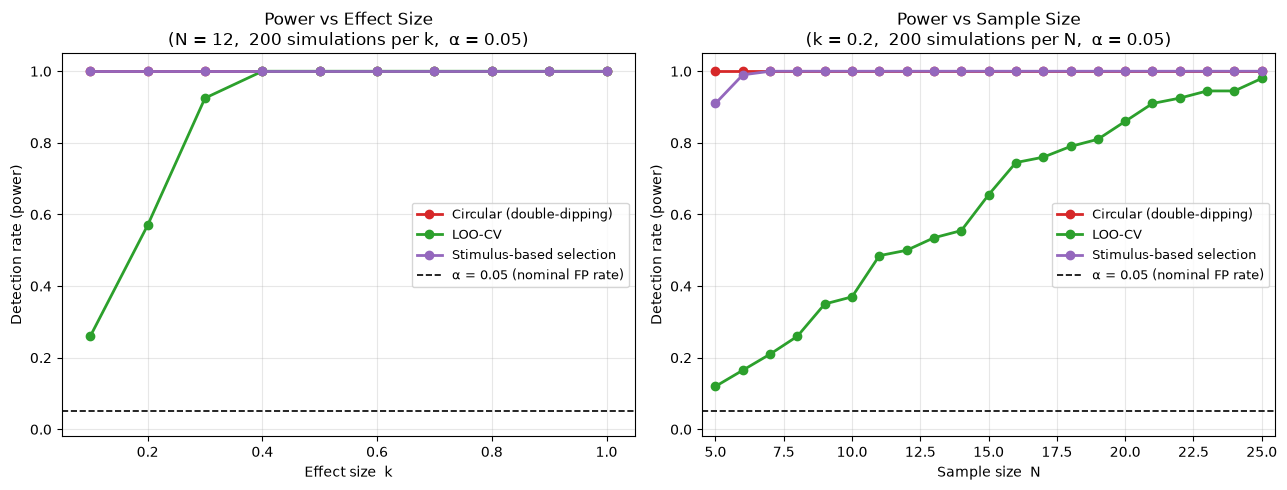

In [21]:
method_styles = {
    "circular": ("tab:red",    "Circular (double-dipping)"),
    "loo_cv":   ("tab:green",  "LOO-CV"),
    "stimulus": ("tab:purple", "Stimulus-based selection"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: power vs effect size k (N=12 fixed)
ax = axes[0]
for m, (color, label) in method_styles.items():
    ax.plot(k_values, power_k[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Effect size  k")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Effect Size\n(N = 12,  {N_iter_power} simulations per k,  α = {alpha_power})")
ax.set_xlim(k_values[0] - 0.05, k_values[-1] + 0.05)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: power vs sample size N (k=0.2 fixed)
ax = axes[1]
for m, (color, label) in method_styles.items():
    ax.plot(N_values, power_N[m], "o-", color=color, label=label, linewidth=2)
ax.axhline(alpha_power, color="k", linestyle="--", linewidth=1.2,
           label=f"α = {alpha_power} (nominal FP rate)")
ax.set_xlabel("Sample size  N")
ax.set_ylabel("Detection rate (power)")
ax.set_title(f"Power vs Sample Size\n(k = 0.2,  {N_iter_power} simulations per N,  α = {alpha_power})")
ax.set_xlim(N_values[0] - 0.5, N_values[-1] + 0.5)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
